# Imports

In [1]:
from fastai.vision.all import *
# from fastai.distributed import * #For distributing across multi GPU
# from sklearn.metrics import roc_curve, auc 
# from fastai.metrics import * 
from sklearn.model_selection import RepeatedKFold, GroupKFold, GroupShuffleSplit, \
                                    StratifiedGroupKFold, LeaveOneGroupOut, LeavePGroupsOut
from sklearn.utils import resample
import sklearn.metrics as skm
from pathlib import Path
import numpy as np
from numpy import random
import shutil
import glob
import os
import pandas as pd
from torch import cuda
import gc
state = 36
# results = Path('/mnt/results/v8/')
# models = results.joinpath('models')
# # csv_path= models.joinpath('resnet18_10fold_1rep_0bal_2ft/csv')
# csv_path= models.joinpath('resnet18_10fold_1rep_250bal_2ft/csv')

In [2]:
%%bash
echo ${SLURM_STEP_GPUS:-$SLURM_JOB_GPUS}

2


In [6]:
torch.cuda.empty_cache()

In [7]:
%%bash
nvidia-smi

Fri Sep 15 10:54:11 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 515.65.01    Driver Version: 515.65.01    CUDA Version: 11.7     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA A100-PCI...  On   | 00000000:3D:00.0 Off |                    0 |
| N/A   40C    P0    91W / 250W |  37977MiB / 40960MiB |     97%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA A100-PCI...  On   | 00000000:3E:00.0 Off |                    0 |
| N/A   

In [2]:
def get_less_used_gpu(gpus=None, debug=False):
    """Inspect cached/reserved and allocated memory on specified gpus and return the id of the less used device"""
    if gpus is None:
        warn = 'Falling back to default: all gpus'
        gpus = range(cuda.device_count())
    elif isinstance(gpus, str):
        gpus = [int(el) for el in gpus.split(',')]

    # check gpus arg VS available gpus
    sys_gpus = list(range(cuda.device_count()))
    if len(gpus) > len(sys_gpus):
        gpus = sys_gpus
        warn = f'WARNING: Specified {len(gpus)} gpus, but only {cuda.device_count()} available. Falling back to default: all gpus.\nIDs:\t{list(gpus)}'
    elif set(gpus).difference(sys_gpus):
        # take correctly specified and add as much bad specifications as unused system gpus
        available_gpus = set(gpus).intersection(sys_gpus)
        unavailable_gpus = set(gpus).difference(sys_gpus)
        unused_gpus = set(sys_gpus).difference(gpus)
        gpus = list(available_gpus) + list(unused_gpus)[:len(unavailable_gpus)]
        warn = f'GPU ids {unavailable_gpus} not available. Falling back to {len(gpus)} device(s).\nIDs:\t{list(gpus)}'

    cur_allocated_mem = {}
    cur_cached_mem = {}
    max_allocated_mem = {}
    max_cached_mem = {}
    for i in gpus:
        cur_allocated_mem[i] = cuda.memory_allocated(i)
        cur_cached_mem[i] = cuda.memory_reserved(i)
        max_allocated_mem[i] = cuda.max_memory_allocated(i)
        max_cached_mem[i] = cuda.max_memory_reserved(i)
    min_allocated = min(cur_allocated_mem, key=cur_allocated_mem.get)
    if debug:
        print(warn)
        print('Current allocated memory:', {f'cuda:{k}': v for k, v in cur_allocated_mem.items()})
        print('Current reserved memory:', {f'cuda:{k}': v for k, v in cur_cached_mem.items()})
        print('Maximum allocated memory:', {f'cuda:{k}': v for k, v in max_allocated_mem.items()})
        print('Maximum reserved memory:', {f'cuda:{k}': v for k, v in max_cached_mem.items()})
        print('Suggested GPU:', min_allocated)
    return min_allocated


def free_memory(to_delete: list, debug=False):
    import gc
    import inspect
    calling_namespace = inspect.currentframe().f_back
    if debug:
        print('Before:')
        get_less_used_gpu(debug=True)

    for _var in to_delete:
        calling_namespace.f_locals.pop(_var, None)
        gc.collect()
        cuda.empty_cache()
    if debug:
        print('After:')
        get_less_used_gpu(debug=True)
        
get_less_used_gpu(debug=True)

Falling back to default: all gpus
Current allocated memory: {'cuda:0': 0}
Current reserved memory: {'cuda:0': 0}
Maximum allocated memory: {'cuda:0': 0}
Maximum reserved memory: {'cuda:0': 0}
Suggested GPU: 0


0

# Flush GPU memory if error etc.

In [6]:
get_less_used_gpu(debug=True)
# del learn
gc.collect()
torch.cuda.empty_cache()
get_less_used_gpu(debug=True)

Falling back to default: all gpus
Current allocated memory: {'cuda:0': 0}
Current reserved memory: {'cuda:0': 0}
Maximum allocated memory: {'cuda:0': 0}
Maximum reserved memory: {'cuda:0': 0}
Suggested GPU: 0
Falling back to default: all gpus
Current allocated memory: {'cuda:0': 0}
Current reserved memory: {'cuda:0': 0}
Maximum allocated memory: {'cuda:0': 0}
Maximum reserved memory: {'cuda:0': 0}
Suggested GPU: 0


0

# Evaluate different model performances with different learning rates etc

In [3]:
df = pd.read_csv('/ix/rbao/Projects/panCancer_HE/data/balanced_5000_sk_lu_lv_cr_df_v1_39992tiles.tsv',
                 sep = '\t')
n = 1000 #very small for debugging
# exc = df.tissue.values == 'lung'
# df = df.loc[~exc,:]
df.loc[:,'tissue_anno'] = df.tissue + df.anno
df_ds = resample(df,n_samples=n,
             random_state=state, 
             replace=False,
             stratify = df.tissue_anno)
df_ds.groupby(['tissue','anno'])['fn'].count()

tissue      anno    
colorectal  Tumor       125
            notTumor    125
liver       Tumor       125
            notTumor    125
lung        Tumor       125
            notTumor    125
skin        Tumor       125
            notTumor    125
Name: fn, dtype: int64

In [4]:
state = 36
splitter = TrainTestSplitter(test_size=0.1, random_state=state, stratify=df_ds.tissue_anno.values,
                    train_size=None, shuffle=True)
batch_size = 128 #5000 seemed too high, resnet18->1000-2000 works, smaller for larger models
                #32 for densenet121 seems to be more predictable w/ learning rates..
                #32 works for densenet169, 128 works, 512 does not work
tissue =DataBlock(blocks=(ImageBlock, CategoryBlock),
                  get_x=ColReader('fn'),
                  splitter=splitter,
                  get_y=  ColReader('anno'),
                  item_tfms=Resize(460), #Presize
                  batch_tfms=aug_transforms(size=224,
                                            max_rotate=30, # size=224,
                                            min_scale=1,
                                            # max_zoom=1.1,
                                            # max_warp=0,
                                            flip_vert=True,
                                            # p_affine=0,
                                            # p_lighting=0.25,
                                           )
                             ) 
dls = tissue.dataloaders(df_ds, bs = batch_size)
dls.show_batch()

Could not do one pass in your dataloader, there is something wrong in it


RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call,so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.

In [16]:
# Many people use Inception V4  or Inception V3 -- > doable here?
learn = cnn_learner(dls, densenet169,
                    metrics=[error_rate, accuracy], # AccumMetric() Recall() ?
                    ).to_fp16()

# # #Reproducibly good:
# learn.fit_one_cycle(10)
# # learn.fit_one_cycle(40)
# # learn.fit_one_cycle(5,4e-3)
# # learn.unfreeze()
# # learn.fit_one_cycle(10,lr_max=1e-3)

# #Test:
# learn.fit_one_cycle(10,0.03)
learn.fit_one_cycle(7,4e-3)
learn.unfreeze()
learn.fit_one_cycle(10,lr_max=1e-3)
learn.fine_tune(5)



/opt/conda/envs/py38/lib/python3.8/site-packages/fastai/vision/learner.py:288: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")
/opt/conda/envs/py38/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/envs/py38/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet169_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet169_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/opt/conda/envs/py38/lib/python3.8/site-packages/torch/amp/autocast_mode.py:204: UserWarning: U

epoch,train_loss,valid_loss,error_rate,accuracy,time


Traceback (most recent call last):
  File "/opt/conda/envs/py38/lib/python3.8/multiprocessing/queues.py", line 245, in _feed
    send_bytes(obj)
  File "/opt/conda/envs/py38/lib/python3.8/multiprocessing/connection.py", line 200, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "/opt/conda/envs/py38/lib/python3.8/multiprocessing/connection.py", line 411, in _send_bytes
    self._send(header + buf)
  File "/opt/conda/envs/py38/lib/python3.8/multiprocessing/connection.py", line 368, in _send
    n = write(self._handle, buf)
BrokenPipeError: [Errno 32] Broken pipe


KeyboardInterrupt: 

In [21]:
lr_min = learn.lr_find() #
print(lr_min)

KeyboardInterrupt: 

In [12]:
learn.fit_one_cycle(10,lr_max=1e-5) #Ran as 5e-3 but I think lower would be better)

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.140486,1.448393,0.432071,0.567929,00:27
1,0.141325,1.475125,0.432071,0.567929,00:29
2,0.140184,1.463033,0.432071,0.567929,00:33
3,0.146975,1.516549,0.432071,0.567929,00:28
4,0.143823,1.505561,0.429844,0.570156,00:28
5,0.142389,1.506831,0.434298,0.565702,00:27
6,0.140259,1.499126,0.434298,0.565702,00:27
7,0.139620,1.481808,0.432071,0.567929,00:27
8,0.139376,1.520002,0.434298,0.565702,00:29
9,0.139863,1.495476,0.432071,0.567929,00:27


SuggestedLRs(valley=0.0014454397605732083)


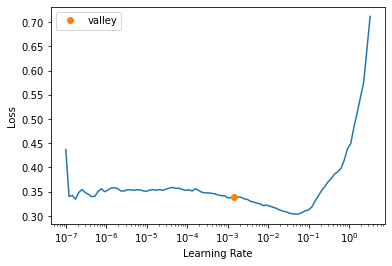

In [49]:
lr_min = learn.lr_find() #
print(lr_min)

In [55]:
learn.unfreeze()
learn.fit_one_cycle(10,lr_max=1e-3)

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.412220,0.211988,0.083827,0.916173,00:24
1,0.438887,0.236556,0.099069,0.900931,00:23
2,0.425820,0.219659,0.087214,0.912786,00:23
3,0.432564,0.155042,0.059272,0.940728,00:24
4,0.433296,0.160829,0.059272,0.940728,00:24
5,0.430229,0.193610,0.076207,0.923793,00:24
6,0.432097,0.211538,0.083404,0.916596,00:24
7,0.406466,0.224563,0.085097,0.914903,00:24
8,0.398771,0.218818,0.085944,0.914056,00:24
9,0.406037,0.217357,0.085097,0.914903,00:23


densenet121, batch size of 32-> fit_one_cycle(5,0.001) -> good. then fit_one_cycle(5,lr_max=5e-4)
densenet121, batch_size = 512 -> fit_one_cycle(5,0.001) -> validation loss just keeps increasing. LR too high?

In [78]:
print(lr_min)

SuggestedLRs(valley=0.00013182566908653826)


# Best sensitivity outcome
densenet169,batch size =128, fit_one_cycle(20),  learn.fit_one_cycle(4,lr_max=2e-3)

2030 220 18 94
sensitivity 0.8392857142857143
specificity 0.9022222222222223
false positive 0.09777777777777778
true positive 0.8392857142857143


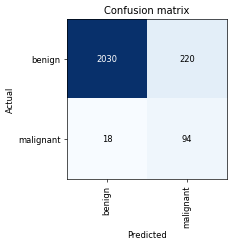

In [31]:
#Plot a confusion matrix
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(4,4), dpi=60)
upp, low = interp.confusion_matrix()
tn, fp = upp[0], upp[1]
fn, tp = low[0], low[1]
print(tn, fp, fn, tp)
sensitivity = tp/(tp + fn) #True pos / all positive
print('sensitivity',sensitivity)

specificity = tn/(fp + tn)
print('specificity',specificity) #True neg / all negative

print('false positive', fp/ (fp + tn))
print('true positive', tp/(tp + fn) )

# Test latest
densenet169, batchsize=128, fit_one_cycle(15),learn.fit_one_cycle(5,lr_max=1e-3) learn.unfreeze()
learn.fit_one_cycle(10,lr_max=1e-4)
--> sensitivity 0.7321428571428571
specificity 0.9542222222222222
false positive 0.04577777777777778
true positive 0.7321428571428571

%Very good: *****
densenet 169, batchsize = 256, learn.fit_one_cycle(40), learn.fit_one_cycle(5,4e-3)
learn.unfreeze()
learn.fit_one_cycle(10,lr_max=1e-3)*****
fold 3-> sensitivity 0.8214285714285714
specificity 0.956
false positive 0.044
true positive 0.8214285714285714

fold 2->
sensitivity 0.9090909090909091
specificity 0.882201646090535
false positive 0.11779835390946503
true positive 0.9090909090909091

fold 8-> sensitivity 0.889763779527559
specificity 0.9168141592920354
false positive 0.0831858407079646
true positive 0.889763779527559

1554 141 42 339
sensitivity 0.889763779527559
specificity 0.9168141592920354
false positive 0.0831858407079646
true positive 0.889763779527559


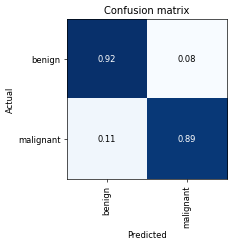

In [68]:
#Plot a confusion matrix
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(normalize=True,
                             figsize=(4,4), dpi=60)
upp, low = interp.confusion_matrix()
tn, fp = upp[0], upp[1]
fn, tp = low[0], low[1]
print(tn, fp, fn, tp)

all_pos = (tp + fn)
sensitivity = tp/all_pos #True positive rate
print('sensitivity',sensitivity)

specificity = tn/(fp + tn) #True negative rate
print('specificity',specificity) #True neg / all negative

print('false positive', fp/ (fp + tn))
print('true positive', tp/all_pos )

113 20 31 115
sensitivity 0.7876712328767124
specificity 0.849624060150376
false positive 0.15037593984962405
true positive 0.7876712328767124


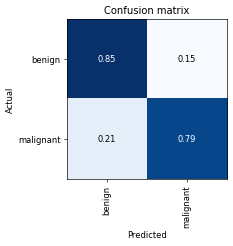

In [5]:
#Plot a confusion matrix
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(normalize=True,
                             figsize=(4,4), dpi=60)
upp, low = interp.confusion_matrix()
tn, fp = upp[0], upp[1]
fn, tp = low[0], low[1]
print(tn, fp, fn, tp)

all_pos = (tp + fn)
sensitivity = tp/all_pos #True positive rate
print('sensitivity',sensitivity)

specificity = tn/(fp + tn) #True negative rate
print('specificity',specificity) #True neg / all negative

print('false positive', fp/ (fp + tn))
print('true positive', tp/all_pos )

# Next step:
see /ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/scripts/biliseq_he_class2/model_fitting/train

in particular: run_batch_slurm_fastai_cnn_fit_v2.sh